# 04 - Final model: official test evaluation, error analysis and explainability

**The configuration was frozen before any use of the official test set** (`FINAL_CONFIG.md`, `configs/final_config.json`). The final models were then trained on all training engines (`python -m src.pipelines.training_pipeline --step train`). After that, the official test set was evaluated **exactly once** (`python -m src.pipelines.evaluate_test`):
1. Predictions were made from the test sensor files.
2. They were saved and hashed **before** any RUL file was opened.
3. The RUL files were then used for scoring only.

This notebook **analyses** those results. Nothing here changes the configuration, the models or the predictions; the test results are not used for any selection.

In [1]:
import json
import os
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_schema import SUBSETS
from src.pipelines.prediction_pipeline import MODEL_DIR, RULPredictor
from src.pipelines.training_pipeline import sha256_file, verify_config_frozen
from src.utils import phm08_score, read_cmapss_file, rul_metrics

EVAL = PROJECT_ROOT / "reports" / "final_evaluation"
FIG_DIR, TAB_DIR = EVAL / "figures", EVAL / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 30)

SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
FD_COLORS = dict(zip(SUBSETS, ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]))
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8, "legend.frameon": False, "figure.dpi": 90,
})


def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    print("saved", (FIG_DIR / f"{name}.png").relative_to(PROJECT_ROOT))


def savetab(df, name, index=True):
    df.to_csv(TAB_DIR / f"{name}.csv", index=index)
    print("saved", (TAB_DIR / f"{name}.csv").relative_to(PROJECT_ROOT))

C:\Users\Mayank\Aircravft_RUL\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Integrity of the freeze and of the one-shot evaluation

In [2]:
cfg = verify_config_frozen()  # raises if the frozen config or feature list changed
manifest = json.load(open(PROJECT_ROOT / MODEL_DIR / "manifest.json", encoding="utf-8"))
log = json.load(open(EVAL / "evaluation_log.json", encoding="utf-8"))
checks = {
    "config frozen at": cfg["frozen"]["at"],
    "models trained at": manifest["trained_at"],
    "test predictions saved at": log["predictions_saved"],
    "RUL labels first read at": log["labels_read"],
    "order freeze < train < predict < labels": cfg["frozen"]["at"] < manifest["trained_at"] < log["predictions_saved"] <= log["labels_read"],
    "config hash unchanged": log["config_body_sha256"] == cfg["frozen"]["config_body_sha256"] == manifest["config_body_sha256"],
    "artifacts unchanged since evaluation": all(sha256_file(str(PROJECT_ROOT / MODEL_DIR / s / f)) == h
                                                for s, d in log["artifact_sha256"].items() for f, h in d.items()),
    "saved predictions unchanged": sha256_file(str(EVAL / "test_predictions_before_labels.csv")) == log["predictions_sha256"],
}
pd.Series(checks, name="value").to_frame()

,value
config frozen at,2026-10-04 21:16:41
models trained at,2026-10-04 21:20:55
test predictions saved at,2026-10-04 21:25:59
RUL labels first read at,2026-10-04 21:25:59
order freeze < train < predict < labels,True
config hash unchanged,True
artifacts unchanged since evaluation,True
saved predictions unchanged,True


In [3]:
# Reproducibility of the inference path: re-predict every official test engine from the raw
# sensor files with freshly loaded (hash-verified) artifacts and compare to the saved predictions.
saved = pd.read_csv(EVAL / "test_predictions_before_labels.csv")
fresh = pd.concat([RULPredictor.load(s).predict_file(f"data/raw/test_{s}.txt").assign(subset=s) for s in SUBSETS], ignore_index=True)
cmp = saved.merge(fresh, on=["subset", "unit_id"], suffixes=("_saved", "_fresh"))
print("engines:", len(cmp), "| max |difference|:", float(np.abs(cmp.predicted_rul_saved - cmp.predicted_rul_fresh).max()),
      "| last cycles identical:", bool((cmp.last_cycle_saved == cmp.last_cycle_fresh).all()))
assert len(cmp) == 707 and np.allclose(cmp.predicted_rul_saved, cmp.predicted_rul_fresh, atol=1e-4)

engines: 707 | max |difference|: 2.842170943040401e-14 | last cycles identical: True


## 2. Official test results

In [4]:
metrics = pd.read_csv(EVAL / "test_metrics.csv")
scored = pd.read_csv(EVAL / "test_predictions_scored.csv")
cv_rows = []
for s in SUBSETS:
    r = metrics.set_index("subset").loc[s]
    cv = cfg["cv_results"][s]
    cv_rows.append({"subset": s, "model": r.model, "cap": r.rul_cap, "engines": int(r.n),
                    "test RMSE": r.rmse, "test MAE": r.mae, "test bias": r.bias, "test PHM08 (sum)": r.phm08_score,
                    "test PHM08/engine": r.phm08_score_per_sample,
                    "CV RMSE primary (RUL≤150)": cv["primary"]["rmse"], "CV RMSE confirm": cv["confirm"]["rmse"],
                    "CV RMSE wide (RUL≤190)": cv["wide"]["rmse"],
                    "share of test engines with RUL > cap": float((scored[scored.subset == s].true_rul > r.rul_cap).mean()),
                    "test RMSE vs capped truth (secondary)": r["rmse_vs_capped_truth (secondary)"]})
results = pd.DataFrame(cv_rows).set_index("subset")
allrow = metrics.set_index("subset").loc["ALL (pooled, 707 engines)"]
results.loc["ALL (707 engines)"] = {"model": "per subset", "engines": 707, "test RMSE": allrow.rmse, "test MAE": allrow.mae,
                                    "test bias": allrow.bias, "test PHM08 (sum)": allrow.phm08_score,
                                    "test PHM08/engine": allrow.phm08_score_per_sample,
                                    "share of test engines with RUL > cap": float((scored.true_rul > scored.rul_cap).mean()),
                                    "test RMSE vs capped truth (secondary)": allrow["rmse_vs_capped_truth (secondary)"]}
savetab(results.round(3), "test_results_vs_cv")
results.round(2)

saved reports\final_evaluation\tables\test_results_vs_cv.csv


,model,cap,engines,test RMSE,test MAE,test bias,test PHM08 (sum),test PHM08/engine,CV RMSE primary (RUL≤150),CV RMSE confirm,CV RMSE wide (RUL≤190),share of test engines with RUL > cap,test RMSE vs capped truth (secondary)
subset,,,,,,,,,,,,,
FD001,xgboost,130.0,100,12.63,9.22,-0.19,227.14,2.27,13.58,13.38,22.70,0.08,12.09
FD002,xgboost,130.0,259,22.52,14.32,-5.85,4342.44,16.77,14.37,14.22,23.11,0.21,11.77
FD003,lightgbm,140.0,100,12.66,8.67,3.07,391.88,3.92,14.00,12.69,21.41,0.04,12.47
FD004,lightgbm,140.0,248,20.70,14.47,-3.67,2199.77,8.87,15.85,16.17,22.71,0.21,13.71
ALL (707 engines),per subset,NaN,707,19.53,12.85,-3.02,7161.23,10.13,NaN,NaN,NaN,0.17,12.62


## 3. Error analysis

### 3.1 Where does the error come from? True-RUL bands relative to the cap

In [5]:
scored = scored.assign(err=scored.predicted_rul - scored.true_rul)
scored["phm"] = [phm08_score([t], [p]) for t, p in zip(scored.true_rul, scored.predicted_rul)]
def band(r):
    if r.true_rul <= 25: return "a) ≤25"
    if r.true_rul <= 50: return "b) 26-50"
    if r.true_rul <= 100: return "c) 51-100"
    if r.true_rul <= r.rul_cap: return "d) 101-cap"
    return "e) > cap"
scored["band"] = scored.apply(band, axis=1)
tot_se = scored.groupby("subset").err.apply(lambda e: (e ** 2).sum())
tot_phm = scored.groupby("subset").phm.sum()
by_band = scored.groupby(["subset", "band"]).apply(lambda g: pd.Series({
    "engines": len(g), "rmse": np.sqrt(np.mean(g.err ** 2)), "bias": g.err.mean(),
    "late > +10": int((g.err > 10).sum()), "early < −10": int((g.err < -10).sum()),
    "share of squared error": (g.err ** 2).sum() / tot_se[g.name[0]],
    "share of PHM08": g.phm.sum() / tot_phm[g.name[0]]})).round(3)
savetab(by_band, "test_errors_by_true_rul_band")
by_band

saved reports\final_evaluation\tables\test_errors_by_true_rul_band.csv


engines    rmse    bias  late > +10  early < −10  share of squared error  share of PHM08
subset band                                                                                                
FD001  a) ≤25         19.0   3.860   0.344         1.0          0.0                   0.018           0.027
       b) 26-50       14.0   5.342  -0.674         0.0          0.0                   0.025           0.033
       c) 51-100      34.0  13.185   5.676        11.0          2.0                   0.371           0.485
       d) 101-cap     25.0  15.744  -2.504         7.0          7.0                   0.389           0.320
       e) > cap        8.0  19.852 -18.277         0.0          6.0                   0.198           0.135
FD002  a) ≤25         58.0   2.871   0.196         0.0          0.0                   0.004           0.003
       b) 26-50       30.0   6.502   0.355         2.0          3.0                   0.010           0.005
       c) 51-100      79.0  16.365   7.074        29.0          7.0                   0.161           0.116
       d) 101-cap     37.0  13.242  -0.313         8.0          8.0                   0.049           0.019
       e) > cap       55.0  43.065 -37.879         0.0         53.0                   0.776           0.857
FD003  a) ≤25         16.0   2.469  -0.225         0.0          0.0                   0.006           0.008
       b) 26-50       13.0   3.512   1.517         0.0          0.0                   0.010           0.011
       c) 51-100      39.0  16.272   8.983        17.0          2.0                   0.644           0.793
       d) 101-cap     28.0  12.207   0.147         5.0          6.0                   0.260           0.157
       e) > cap        4.0  17.840 -15.902         0.0          2.0                   0.079           0.031
FD004  a) ≤25         50.0   5.958   2.971         5.0          0.0                   0.017           0.016
       b) 26-50       30.0   5.787   1.348         4.0          0.0                   0.009           0.009
       c) 51-100      68.0  19.923   7.589        24.0          9.0                   0.254           0.382
       d) 101-cap     48.0  13.338   2.003        15.0         11.0                   0.080           0.057
       e) > cap       52.0  36.158 -32.932         0.0         49.0                   0.640           0.536

In [6]:
# Test metrics restricted to the RUL range the primary CV plan represents (true RUL ≤ 150)
# and to engines at or below the cap: how much of the gap to CV is the cap?
rows = []
for s in SUBSETS:
    d = scored[scored.subset == s]
    for name, mask in [("all engines", d.true_rul > -1), ("true RUL ≤ 150 (primary-CV range)", d.true_rul <= 150),
                       ("true RUL ≤ cap", d.true_rul <= d.rul_cap)]:
        m = rul_metrics(d[mask].true_rul, d[mask].predicted_rul)
        rows.append({"subset": s, "engines": name, "n": m["n"], "rmse": m["rmse"], "bias": m["bias"],
                     "PHM08/engine": m["phm08_score_per_sample"]})
restricted = pd.DataFrame(rows).round(2)
savetab(restricted, "test_metrics_restricted", index=False)
restricted.pivot(index="engines", columns="subset", values="rmse")

saved reports\final_evaluation\tables\test_metrics_restricted.csv


subset,FD001,FD002,FD003,FD004
engines,,,,
all engines,12.63,22.52,12.66,20.70
true RUL ≤ 150 (primary-CV range),12.63,13.12,12.66,14.31
true RUL ≤ cap,11.79,12.00,12.40,13.98


saved reports\final_evaluation\figures\01_pred_vs_true.png


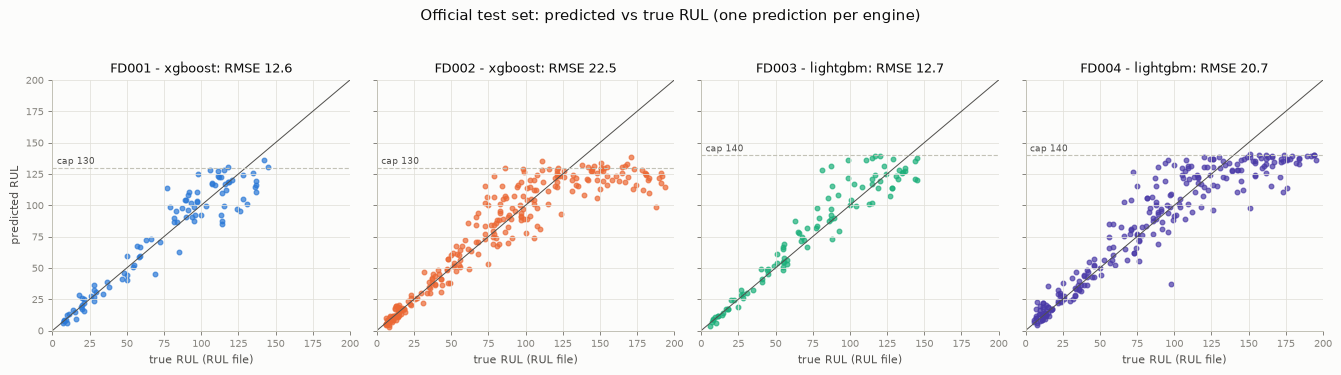

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharex=True, sharey=True)
for ax, s in zip(axes, SUBSETS):
    d = scored[scored.subset == s]
    cap = d.rul_cap.iloc[0]
    ax.scatter(d.true_rul, d.predicted_rul, s=14, alpha=0.7, color=FD_COLORS[s])
    ax.plot([0, 200], [0, 200], color=INK2, lw=0.8)
    ax.axhline(cap, color=AXIS, ls="--", lw=0.9)
    ax.text(3, cap + 3, f"cap {cap:g}", fontsize=7.5, color=INK2)
    r = results.loc[s]
    ax.set(title=f"{s} - {r.model}: RMSE {r['test RMSE']:.1f}", xlabel="true RUL (RUL file)", xlim=(0, 200), ylim=(0, 200))
axes[0].set_ylabel("predicted RUL")
fig.suptitle("Official test set: predicted vs true RUL (one prediction per engine)", y=1.03)
fig.tight_layout()
savefig(fig, "01_pred_vs_true")
plt.show()

### 3.2 Observed history length and implied lifespan

In [8]:
scored["hist"] = pd.cut(scored.last_cycle, [0, 30, 60, 100, 150, 600], labels=["≤30", "31-60", "61-100", "101-150", ">150"])
by_hist = scored.groupby(["subset", "hist"], observed=True).apply(lambda g: pd.Series({
    "engines": len(g), "rmse": np.sqrt(np.mean(g.err ** 2)), "bias": g.err.mean(), "mean true RUL": g.true_rul.mean()})).round(2)
savetab(by_hist, "test_errors_by_history_length")
by_hist.unstack("subset")

saved reports\final_evaluation\tables\test_errors_by_history_length.csv


engines                       rmse                       bias                      mean true RUL                        
subset    FD001  FD002 FD003  FD004  FD001  FD002  FD003  FD004 FD001  FD002  FD003  FD004         FD001   FD002   FD003   FD004
hist                                                                                                                            
≤30         NaN    6.0   NaN   11.0    NaN  25.51    NaN  31.73   NaN -13.25    NaN -18.79           NaN  144.83     NaN  157.45
31-60      12.0   33.0   6.0   16.0  14.02  31.63  28.12  25.50  8.29  -9.28  14.19  -4.61        116.33  133.06  119.00  138.62
61-100     18.0   53.0  15.0   33.0  16.00  36.27  15.65  30.71  1.49 -17.03   5.60  -3.70        110.39  128.89  116.60  127.88
101-150    34.0   67.0  30.0   61.0  12.87  16.70  12.25  20.55 -1.59  -0.76   5.99  -2.94         67.50   70.55   77.57   83.62
>150       36.0  100.0  49.0  127.0   9.65   7.80   7.97  14.83 -2.53  -1.74  -0.86  -2.60         52.06   42.09   55.96   64.52

In [9]:
# Lifespan-dependent bias on the test set: implied lifespan = observed length + true RUL (evaluation only).
# Restricted to engines with true RUL <= cap so the cap does not masquerade as lifespan bias.
rows = []
for s in SUBSETS:
    d = scored[(scored.subset == s)].assign(life=lambda x: x.last_cycle + x.true_rul)
    for name, dd in [("all engines", d), ("true RUL ≤ cap", d[d.true_rul <= d.rul_cap])]:
        terc = pd.qcut(dd.life, 3, labels=["short-lived", "mid", "long-lived"])
        rows.append({"subset": s, "engines": name, "n": len(dd), "corr(error, implied lifespan)": np.corrcoef(dd.err, dd.life)[0, 1]}
                    | dd.groupby(terc, observed=True).err.mean().add_prefix("bias ").to_dict()
                    | {"late > +10 among short-lived": int((dd.err[terc == "short-lived"] > 10).sum())})
life_bias = pd.DataFrame(rows).round(2)
savetab(life_bias, "test_lifespan_bias", index=False)
life_bias

saved reports\final_evaluation\tables\test_lifespan_bias.csv


,subset,engines,n,"corr(error, implied lifespan)",bias short-lived,bias mid,bias long-lived,late > +10 among short-lived
0,FD001,all engines,100,-0.55,8.11,-2.00,-6.92,14
1,FD001,true RUL ≤ cap,92,-0.54,8.36,-0.34,-4.04,13
2,FD002,all engines,259,-0.44,7.13,-7.09,-18.02,30
3,FD002,true RUL ≤ cap,204,-0.43,10.07,1.13,-2.83,28
4,FD003,all engines,100,-0.34,8.93,0.71,-0.86,14
5,FD003,true RUL ≤ cap,96,-0.37,9.95,1.46,-0.10,14
6,FD004,all engines,248,-0.31,7.23,-8.91,-9.42,27
7,FD004,true RUL ≤ cap,196,-0.34,10.37,1.74,-0.02,24


In [10]:
worst = scored.assign(abs_err=scored.err.abs()).sort_values("abs_err", ascending=False).groupby("subset").head(5)
worst = worst[["subset", "unit_id", "last_cycle", "true_rul", "predicted_rul", "err", "phm", "rul_cap"]].round(1)
savetab(worst, "test_worst_engines", index=False)
print("PHM08 share of the 5 worst engines per subset:",
      (worst.groupby("subset").phm.sum() / tot_phm).round(2).to_dict())
worst

saved reports\final_evaluation\tables\test_worst_engines.csv
PHM08 share of the 5 worst engines per subset: {'FD001': 0.36, 'FD002': 0.5, 'FD003': 0.64, 'FD004': 0.31}


,subset,unit_id,last_cycle,true_rul,predicted_rul,err,phm,rul_cap
265,FD002,166,97,188,98.5,-89.5,979.7,130.0
185,FD002,86,83,194,115.0,-79.0,436.3,130.0
287,FD002,188,86,183,109.7,-73.3,279.4,130.0
355,FD002,256,59,191,118.1,-72.9,270.8,130.0
302,FD002,203,115,192,123.4,-68.6,195.3,130.0
611,FD004,153,130,173,110.6,-62.4,120.3,140.0
512,FD004,54,81,176,113.7,-62.3,119.9,140.0
698,FD004,240,204,98,37.3,-60.7,105.9,140.0
585,FD004,127,98,195,136.0,-59.0,92.7,140.0
624,FD004,166,63,72,126.9,54.9,241.7,140.0


In [11]:
late = scored.groupby("subset").apply(lambda g: pd.Series({
    "engines": len(g), "late > +10": int((g.err > 10).sum()), "late > +20": int((g.err > 20).sum()),
    "early < −20": int((g.err < -20).sum()), "max late error": g.err.max(), "max early error": g.err.min()})).round(1)
savetab(late, "test_late_early_counts")
late

saved reports\final_evaluation\tables\test_late_early_counts.csv


,engines,late > +10,late > +20,early < −20,max late error,max early error
subset,,,,,,
FD001,100.0,19.0,3.0,12.0,37.2,-30.5
FD002,259.0,39.0,18.0,48.0,44.5,-89.5
FD003,100.0,22.0,10.0,2.0,46.9,-25.2
FD004,248.0,48.0,23.0,43.0,54.9,-62.4


**Result.**
- **The cap explains most of the FD002/FD004 gap.**
  - 21% of FD002 and FD004 test engines (55 and 52) have a true RUL above the cap. Those engines carry **78% (FD002) and 64% (FD004) of the squared error**, and 86% and 54% of the PHM08 score. They are all predicted **early** (bias −38 and −33 cycles).
  - Restricted to true RUL ≤ 150, the range the primary CV plan covers, test RMSE is **12.6 / 13.1 / 12.7 / 14.3**. That is at or below the CV estimates of 13.6 / 14.4 / 14.0 / 15.9.
  - The CV protocol was therefore accurate within its range. The miss is the RUL range: the primary plan had no samples above 150. The wide-plan CV estimates (22.7 / 23.1 / 21.4 / 22.7) anticipated the full-test RMSE for FD002/FD004 (22.5 / 20.7).
- **Late predictions sit at true RUL 51-100**, as in CV: bias +5.7 to +9.0, with 11-29 engines per subset more than 10 cycles late.
- **Short histories** (≤ 60 observed cycles) are the worst in FD002/FD004 (RMSE 25-32), because they combine little evidence with large true RULs.
- **Lifespan-dependent bias is confirmed on the test set.**
  - Short-lived engines (implied lifespan) are predicted 8-10 cycles late, even when restricted to RUL ≤ cap.
  - corr(error, lifespan) is −0.31 to −0.55.
  - The single worst late prediction is FD004 unit 166 (true 72, predicted 127): a fast degrader seen at only 63 cycles.

## 4. Explainability: SHAP (TreeExplainer) on the finalized models

Exact tree SHAP values for every official test engine at its prediction row, i.e. the last observed cycle. Values are in RUL cycles, before the ≥ 0 clipping. Additivity is checked: base value + Σ SHAP = model output.

In [12]:
shap_data = {}
for s in SUBSETS:
    p = RULPredictor.load(s)
    f = p.features(read_cmapss_file(s, "test"))
    last = f.loc[f.groupby("unit_id").cycle.idxmax()].sort_values("unit_id")
    X = last[p.preprocessor.feature_names_].to_numpy(np.float32)
    ex = shap.TreeExplainer(p.model)
    sv = ex.shap_values(X)
    base = float(np.ravel(ex.expected_value)[0])
    raw = np.asarray(p.model.predict(X), float)
    print(f"{s} {type(p.model).__name__}: SHAP {sv.shape}, base value {base:.1f}, additivity max error {np.abs(sv.sum(1) + base - raw).max():.2e}")
    shap_data[s] = {"sv": sv, "X": X, "base": base, "units": last.unit_id.to_numpy(), "meta": p.preprocessor.feature_meta_,
                    "names": p.preprocessor.feature_names_, "pre": p.preprocessor}

FD001 XGBRegressor: SHAP (100, 290), base value 88.7, additivity max error 1.07e-04


FD002 XGBRegressor: SHAP (259, 290), base value 88.8, additivity max error 1.45e-04


FD003 LGBMRegressor: SHAP (100, 290), base value 100.1, additivity max error 4.55e-13


FD004 LGBMRegressor: SHAP (248, 290), base value 99.9, additivity max error 5.12e-13


In [13]:
def aggregate(s, key):
    d = shap_data[s]
    m = d["meta"].set_index("feature").loc[d["names"]]
    lab = m[key].to_numpy()
    df = pd.DataFrame(np.abs(d["sv"]), columns=d["names"])
    # sum |SHAP| within each group/sensor per engine (block attribution), then mean over engines
    return pd.Series({g: df.loc[:, lab == g].sum(axis=1).mean() for g in np.unique(lab)})

shap_group = pd.DataFrame({s: aggregate(s, "group") for s in SUBSETS})
shap_group["mean"] = shap_group.mean(axis=1)
shap_sensor = pd.DataFrame({s: aggregate(s, "sensor") for s in SUBSETS})
shap_sensor["mean"] = shap_sensor.mean(axis=1)
savetab(shap_group.sort_values("mean", ascending=False).round(2), "shap_by_group")
savetab(shap_sensor.sort_values("mean", ascending=False).round(2), "shap_by_sensor")
display(shap_group.sort_values("mean", ascending=False).round(2))
shap_sensor.sort_values("mean", ascending=False).round(2)

saved reports\final_evaluation\tables\shap_by_group.csv
saved reports\final_evaluation\tables\shap_by_sensor.csv


,FD001,FD002,FD003,FD004,mean
baseline,37.849998,40.290001,41.46,42.02,40.40
mean,11.870000,12.650000,9.86,11.67,11.51
minmax,8.540000,9.070000,9.28,12.90,9.95
cycle,5.700000,6.640000,5.86,6.07,6.07
slope,6.160000,4.290000,6.51,4.87,5.46
delta,2.950000,4.670000,3.24,3.93,3.70
std,2.340000,1.340000,2.12,2.79,2.15
current,0.020000,0.000000,0.07,0.02,0.03


,FD001,FD002,FD003,FD004,mean
Ps30,11.76,19.17,17.43,24.18,18.14
T50,10.04,12.20,15.10,11.22,12.14
cycle,5.70,6.64,5.86,6.07,6.07
BPR,6.65,11.03,1.83,3.59,5.77
Nc,4.31,3.16,5.07,6.13,4.67
NRc,4.78,3.96,4.43,5.13,4.57
htBleed,1.99,3.67,5.63,6.48,4.44
T24,3.95,4.56,4.20,4.32,4.26
phi,5.69,1.13,3.69,2.24,3.19
T30,2.26,2.98,2.81,3.46,2.88


saved reports\final_evaluation\figures\02_shap_group_sensor.png


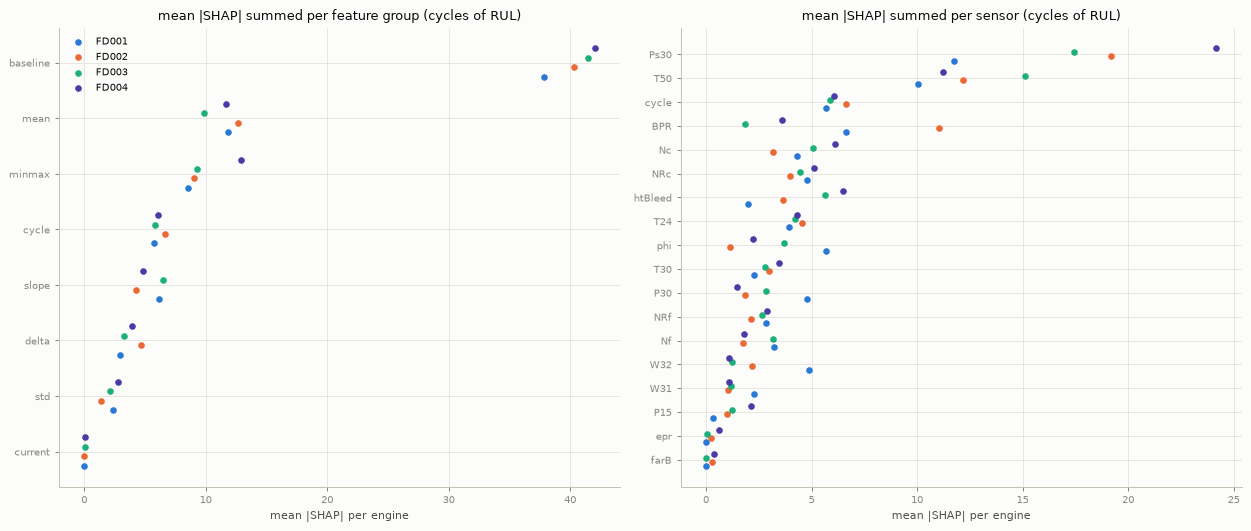

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, tab, title in [(axes[0], shap_group, "feature group"), (axes[1], shap_sensor, "sensor")]:
    order = tab["mean"].sort_values().index
    y = np.arange(len(order))
    for i, s in enumerate(SUBSETS):
        ax.scatter(tab.loc[order, s], y + (i - 1.5) * 0.17, s=18, color=FD_COLORS[s], label=s, zorder=3)
    ax.set_yticks(y, order)
    ax.set(title=f"mean |SHAP| summed per {title} (cycles of RUL)", xlabel="mean |SHAP| per engine")
axes[0].legend()
fig.tight_layout()
savefig(fig, "02_shap_group_sensor")
plt.show()

In [15]:
top = pd.DataFrame({s: pd.Series(np.abs(shap_data[s]["sv"]).mean(0), index=shap_data[s]["names"]) for s in SUBSETS})
top["mean"] = top.mean(axis=1)
top = top.sort_values("mean", ascending=False).head(15).round(2)
savetab(top, "shap_top15_features")
top

saved reports\final_evaluation\tables\shap_top15_features.csv


,FD001,FD002,FD003,FD004,mean
Ps30_delta_base,8.40,13.87,12.21,16.19,12.67
T50_delta_base,6.81,6.71,11.87,7.32,8.18
cycle_feature,5.70,6.64,5.86,6.07,6.07
BPR_delta_base,4.67,7.42,0.69,1.59,3.59
Nc_delta_base,1.43,1.41,2.74,3.68,2.32
htBleed_delta_base,0.28,2.28,3.07,3.43,2.27
NRc_delta_base,1.80,2.31,2.05,2.44,2.15
T24_delta_base,0.33,1.74,2.69,2.17,1.73
phi_delta_base,3.65,0.23,1.48,0.98,1.59
P30_delta_base,3.11,0.66,0.89,0.48,1.28


saved reports\final_evaluation\figures\03_shap_dependence.png


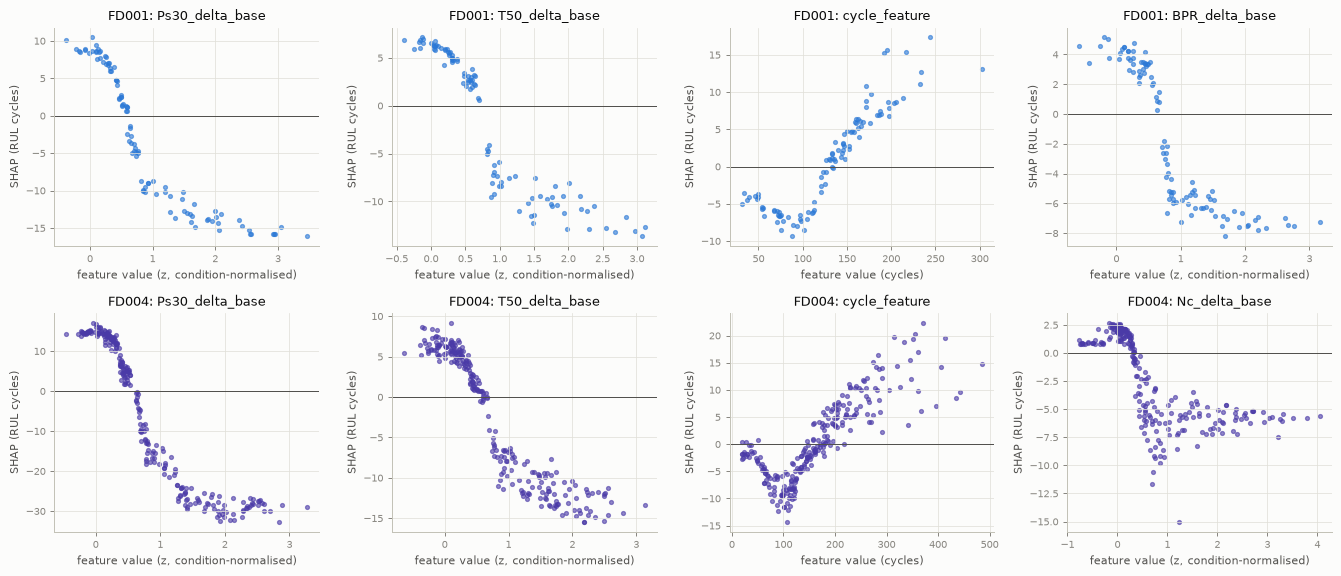

In [16]:
# Direction of the main effects: SHAP of the top features vs the (scaled) feature value, FD004 and FD001.
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
for row, s in enumerate(["FD001", "FD004"]):
    d = shap_data[s]
    imp_s = pd.Series(np.abs(d["sv"]).mean(0), index=d["names"]).sort_values(ascending=False).index[:4]
    for ax, f in zip(axes[row], imp_s):
        j = d["names"].index(f)
        val = d["X"][:, j] * d["pre"].std_[f] + d["pre"].mean_[f]  # back to unscaled (z / cycles)
        ax.scatter(val, d["sv"][:, j], s=10, alpha=0.6, color=FD_COLORS[s])
        ax.axhline(0, color=INK2, lw=0.8)
        ax.set(title=f"{s}: {f}", xlabel="feature value" + (" (cycles)" if f == "cycle_feature" else " (z, condition-normalised)"),
               ylabel="SHAP (RUL cycles)")
fig.tight_layout()
savefig(fig, "03_shap_dependence")
plt.show()

In [17]:
# Local explanations: the largest LATE prediction and the largest EARLY prediction on the test set.
def explain(s, unit, k=8):
    d = shap_data[s]
    i = int(np.where(d["units"] == unit)[0][0])
    contrib = pd.Series(d["sv"][i], index=d["names"])
    topk = contrib.reindex(contrib.abs().sort_values(ascending=False).index[:k]).round(1)
    r = scored[(scored.subset == s) & (scored.unit_id == unit)].iloc[0]
    print(f"{s} unit {unit}: observed {r.last_cycle} cycles, true RUL {r.true_rul}, predicted {r.predicted_rul:.1f} "
          f"(error {r.err:+.1f}); base value {d['base']:.1f} + Σ SHAP {contrib.sum():+.1f}")
    return topk.to_frame("SHAP (cycles)")

late_row = scored.loc[scored.err.idxmax()]
early_row = scored.loc[scored.err.idxmin()]
display(explain(late_row.subset, int(late_row.unit_id)))
explain(early_row.subset, int(early_row.unit_id))

FD004 unit 166: observed 63 cycles, true RUL 72, predicted 126.9 (error +54.9); base value 99.9 + Σ SHAP +27.0


,SHAP (cycles)
Ps30_delta_base,13.8
cycle_feature,-7.2
T50_delta_base,6.6
htBleed_delta_base,2.3
Nc_delta_base,2.1
P15_max30,-1.7
T30_delta_base,1.5
BPR_delta_base,1.3


FD002 unit 166: observed 97 cycles, true RUL 188, predicted 98.5 (error -89.5); base value 88.8 + Σ SHAP +9.6


,SHAP (cycles)
Ps30_delta_base,11.7
cycle_feature,-9.9
T50_delta_base,-8.2
htBleed_delta_base,-4.1
W32_delta_base,2.4
T50_mean10,2.0
Ps30_mean10,1.8
T24_delta_base,1.6


**Result (SHAP agrees with the CV permutation importance).**
- **By group:** change from the engine's own early-life **baseline** dominates (mean |SHAP| ≈ 40 cycles per engine, summed over the group). It is followed by trailing mean (11.5), min/max (10), cycle (6), slope (5.5) and delta (3.7). The raw current value contributes nothing.
- **By sensor:** **Ps30** (18) and **T50** (12) lead, followed by cycle (6), BPR (5.8; 11 in FD002), Nc/NRc, htBleed and T24. epr and farB contribute ≈ 0.
- **Top single features:** Ps30_delta_base, T50_delta_base, cycle_feature, BPR_delta_base.
- **Directions are physically sensible:** a larger rise in Ps30/T50 since baseline lowers the predicted RUL, and older engines get lower RUL.
- **The failure cases explain themselves:**
  - The worst *late* prediction comes from Ps30 and T50 having changed little since baseline (+14 and +7 cycles), with cycle pulling only −7.
  - The worst *early* prediction (true 188) is the cap at work: the model cannot exceed about 130, and the SHAP terms only move it within the capped range.

## 5. Inference-path tests

In [18]:
res = subprocess.run([sys.executable, "-m", "pytest", "tests/test_inference.py", "-q", "-p", "no:cacheprovider"],
                     cwd=PROJECT_ROOT, capture_output=True, text=True)
print(res.stdout.strip().splitlines()[-1])
assert res.returncode == 0

10 passed in 18.15s


## 6. Summary

See `reports/final_evaluation/FINAL_EVALUATION_REPORT.md`.